<a href="https://colab.research.google.com/github/nishasn10/Aiml_project/blob/main/Kmeans_un.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Dataset Loaded Successfully!
   CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)
0           1    Male   19                  15                      39
1           2    Male   21                  15                      81
2           3  Female   20                  16                       6
3           4  Female   23                  16                      77
4           5  Female   31                  17                      40

Dataset Shape: (200, 5)


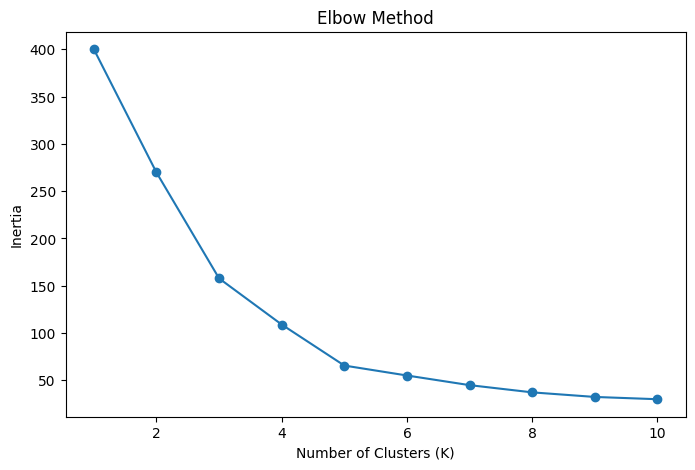


Clustered Data:
    CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0            1    Male   19                  15                      39   
1            2    Male   21                  15                      81   
2            3  Female   20                  16                       6   
3            4  Female   23                  16                      77   
4            5  Female   31                  17                      40   
5            6  Female   22                  17                      76   
6            7  Female   35                  18                       6   
7            8  Female   23                  18                      94   
8            9    Male   64                  19                       3   
9           10  Female   30                  19                      72   
10          11    Male   67                  19                      14   
11          12  Female   35                  19                      99   
12      

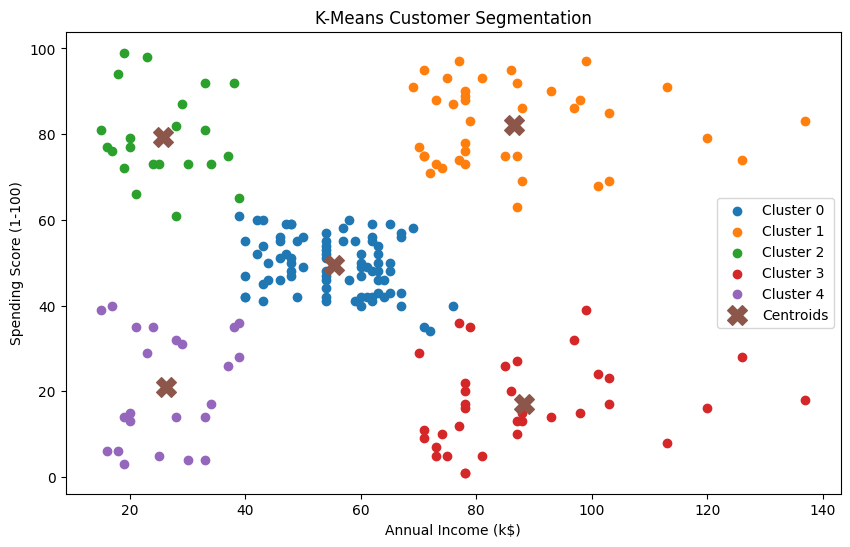


Number of Customers in Each Cluster:
Cluster
0    81
1    39
2    22
3    35
4    23
Name: count, dtype: int64

K-MEANS CLUSTERING COMPLETED

Final Dataset:
     CustomerID   Genre  Age  Annual Income (k$)  Spending Score (1-100)  \
0             1    Male   19                  15                      39   
1             2    Male   21                  15                      81   
2             3  Female   20                  16                       6   
3             4  Female   23                  16                      77   
4             5  Female   31                  17                      40   
..          ...     ...  ...                 ...                     ...   
195         196  Female   35                 120                      79   
196         197  Female   45                 126                      28   
197         198    Male   32                 126                      74   
198         199    Male   32                 137                      18   
199   

In [4]:
# ============================================
# K-MEANS CLUSTERING - MALL CUSTOMERS
# Unsupervised Machine Learning
# ============================================

import pandas as pd
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

# ============================================
# 1. LOAD DATASET
# ============================================

df = pd.read_csv("/content/Mall_Customers.csv")

print("Dataset Loaded Successfully!")
print(df.head())
print("\nDataset Shape:", df.shape)

# ============================================
# 2. SELECT FEATURES
# ============================================

X = df[[
    "Annual Income (k$)",
    "Spending Score (1-100)"
]]

# ============================================
# 3. FEATURE SCALING
# ============================================

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X)

# ============================================
# 4. ELBOW METHOD
# ============================================

inertia = []

for k in range(1, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=10
    )

    kmeans.fit(X_scaled)

    inertia.append(kmeans.inertia_)

# Plot Elbow Curve

plt.figure(figsize=(8, 5))

plt.plot(
    range(1, 11),
    inertia,
    marker="o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method")

plt.show()

# ============================================
# 5. APPLY K-MEANS
# ============================================

# Based on the Elbow Method

kmeans = KMeans(
    n_clusters=5,
    random_state=42,
    n_init=10
)

# Create clusters

df["Cluster"] = kmeans.fit_predict(X_scaled)

# ============================================
# 6. DISPLAY CLUSTER RESULTS
# ============================================

print("\nClustered Data:")
print(df.head(20))

# ============================================
# 7. CLUSTER CENTERS
# ============================================

centers = kmeans.cluster_centers_

# Convert centers back to original scale

centers_original = scaler.inverse_transform(centers)

print("\nCluster Centers:")

for i, center in enumerate(centers_original):

    print(
        f"Cluster {i}: "
        f"Annual Income = {center[0]:.2f} k$, "
        f"Spending Score = {center[1]:.2f}"
    )

# ============================================
# 8. VISUALIZE CLUSTERS
# ============================================

plt.figure(figsize=(10, 6))

for cluster in range(5):

    cluster_data = df[df["Cluster"] == cluster]

    plt.scatter(
        cluster_data["Annual Income (k$)"],
        cluster_data["Spending Score (1-100)"],
        label=f"Cluster {cluster}"
    )

# Plot cluster centers

plt.scatter(
    centers_original[:, 0],
    centers_original[:, 1],
    marker="X",
    s=200,
    label="Centroids"
)

plt.xlabel("Annual Income (k$)")
plt.ylabel("Spending Score (1-100)")

plt.title("K-Means Customer Segmentation")

plt.legend()

plt.show()

# ============================================
# 9. CLUSTER COUNT
# ============================================

print("\nNumber of Customers in Each Cluster:")

print(
    df["Cluster"].value_counts().sort_index()
)

# ============================================
# 10. FINAL OUTPUT
# ============================================

print("\n================================")
print("K-MEANS CLUSTERING COMPLETED")
print("================================")

print("\nFinal Dataset:")
print(df)